In [1]:
import pandas as pd
import numpy as np

In [24]:
df = pd.read_csv('datas/train_and_test2.csv')

In [25]:
df

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,28.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1305,1306,39.0,108.9000,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,0
1306,1307,38.5,7.2500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1307,1308,28.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [2]:
df = pd.read_csv('datas/diabetes2.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
theta = np.array([0,0,0,0, 0, 0, 0, 0, 0])

In [3]:
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

In [4]:
X = df[features].copy()

In [5]:
X.head(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31


In [6]:
y = df['Outcome'].copy()

In [7]:
y.head()

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

In [8]:
y.shape

(768,)

In [12]:
X.shape

(768, 8)

In [13]:
theta.shape

(9,)

In [9]:
ones = pd.Series(np.ones(X.shape[0]))

In [19]:
ones.shape

(768,)

In [10]:
X = pd.concat([ones, X], axis=1)

In [11]:
X.columns

Index([                         0,              'Pregnancies',
                        'Glucose',            'BloodPressure',
                  'SkinThickness',                  'Insulin',
                            'BMI', 'DiabetesPedigreeFunction',
                            'Age'],
      dtype='object')

In [ ]:
theta.shape

In [31]:
X.shape

(768, 9)

In [35]:
theta[0] = 1
theta[2] = 1

In [38]:
(theta*X).sum(axis=1)

0      149.0
1       86.0
2      184.0
3       90.0
4      138.0
       ...  
763    102.0
764    123.0
765    122.0
766    127.0
767     94.0
Length: 768, dtype: float64

In [13]:
theta = np.array([0,0,0,0, 0, 0, 0, 0, 0])

h0 = (theta*X).sum(axis=1)

In [44]:

np.exp(np.arange(4).reshape(2,2))

array([[ 1.        ,  2.71828183],
       [ 7.3890561 , 20.08553692]])

In [14]:
h = (1/(1+(np.exp(((-1)*(h0.values))))))

In [15]:
cost = (-y)*np.log(h) -((1-y)*np.log(1-h))

In [17]:
m = X.shape[0]

In [71]:
(1/m)*(cost.sum())

0.6931471805599452

In [73]:
h.shape

(768,)

In [20]:
cost_matrix = []
alpha = 0.00000001
theta = np.array([0,20,0,1, 10, 11, 0, 0, 0])
for i in range(30):
    h0 = (theta*X).sum(axis=1)
    h = (1/(1+(np.exp(((-1)*(h0.values))))))
    print(theta)
    cost0 = (-y)*np.log(h) -((1-y)*np.log(1-h))
    cost = (1/m)*(cost0.sum())
    print(cost)
    cost_matrix.append(cost)
    for j in range(theta.shape[0]):
        theta[j] = theta[j] - (alpha*(1/m)*((h-y)*X.iloc[:, j]).sum())

[ 0 20  0  1 10 11  0  0  0]
inf
[ 0 19  0  0  9 10  0  0  0]
inf
[ 0 18  0  0  8  9  0  0  0]
inf
[ 0 17  0  0  7  8  0  0  0]
inf
[ 0 16  0  0  6  7  0  0  0]
inf
[ 0 15  0  0  5  6  0  0  0]
inf
[ 0 14  0  0  4  5  0  0  0]
inf
[ 0 13  0  0  3  4  0  0  0]
inf
[ 0 12  0  0  2  3  0  0  0]
inf
[ 0 11  0  0  1  2  0  0  0]
inf
[ 0 10  0  0  0  1  0  0  0]
inf
[0 9 0 0 0 0 0 0 0]
inf
[0 8 0 0 0 0 0 0 0]
inf
[0 7 0 0 0 0 0 0 0]
inf
[0 6 0 0 0 0 0 0 0]
inf
[0 5 0 0 0 0 0 0 0]
inf
[0 4 0 0 0 0 0 0 0]
inf


/home/bishal/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:8: RuntimeWarning: divide by zero encountered in log
  


[0 3 0 0 0 0 0 0 0]
inf
[0 2 0 0 0 0 0 0 0]
4.419473362841797
[0 1 0 0 0 0 0 0 0]
2.326493001924113
[0 0 0 0 0 0 0 0 0]
0.6931471805599452
[0 0 0 0 0 0 0 0 0]
0.6931471805599452
[0 0 0 0 0 0 0 0 0]
0.6931471805599452
[0 0 0 0 0 0 0 0 0]
0.6931471805599452
[0 0 0 0 0 0 0 0 0]
0.6931471805599452
[0 0 0 0 0 0 0 0 0]
0.6931471805599452
[0 0 0 0 0 0 0 0 0]
0.6931471805599452
[0 0 0 0 0 0 0 0 0]
0.6931471805599452
[0 0 0 0 0 0 0 0 0]
0.6931471805599452
[0 0 0 0 0 0 0 0 0]
0.6931471805599452


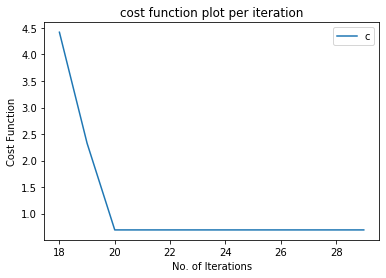

In [21]:
import matplotlib.pyplot as plt

plt.plot([i for i in range(len(cost_matrix))], cost_matrix)
plt.xlabel('No. of Iterations')
plt.ylabel('Cost Function')
plt.title('cost function plot per iteration')
plt.legend('cost')

In [22]:
theta

array([0, 0, 0, 0, 0, 0, 0, 0, 0])

In [26]:
df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [37]:
features = ['Age', 'Sex']
X = df[features].copy()
y = df['2urvived'].copy()

In [38]:
X = pd.concat([pd.Series(np.ones(X.shape[0])), X], axis=1)

In [39]:
X

,0,Age,Sex
0,1.0,22.0,0
1,1.0,38.0,1
2,1.0,26.0,1
3,1.0,35.0,1
4,1.0,35.0,0
...,...,...,...
1304,1.0,28.0,0
1305,1.0,39.0,1
1306,1.0,38.5,0
1307,1.0,28.0,0


In [40]:
cost_matrix = []
alpha = 0.0001
theta = np.array([0, 0, 0])
for i in range(30):
    h0 = (theta*X).sum(axis=1)
    h = (1/(1+(np.exp(((-1)*(h0.values))))))
    print(theta)
    cost0 = (-y)*np.log(h) -((1-y)*np.log(1-h))
    cost = (1/m)*(cost0.sum())
    print(cost)
    cost_matrix.append(cost)
    for j in range(theta.shape[0]):
        theta[j] = theta[j] - (alpha*(1/m)*((h-y)*X.iloc[:, j]).sum())

[0 0 0]
1.1814188272825108
[0 0 0]
1.1814188272825108
[0 0 0]
1.1814188272825108
[0 0 0]
1.1814188272825108
[0 0 0]
1.1814188272825108
[0 0 0]
1.1814188272825108
[0 0 0]
1.1814188272825108
[0 0 0]
1.1814188272825108
[0 0 0]
1.1814188272825108
[0 0 0]
1.1814188272825108
[0 0 0]
1.1814188272825108
[0 0 0]
1.1814188272825108
[0 0 0]
1.1814188272825108
[0 0 0]
1.1814188272825108
[0 0 0]
1.1814188272825108
[0 0 0]
1.1814188272825108
[0 0 0]
1.1814188272825108
[0 0 0]
1.1814188272825108
[0 0 0]
1.1814188272825108
[0 0 0]
1.1814188272825108
[0 0 0]
1.1814188272825108
[0 0 0]
1.1814188272825108
[0 0 0]
1.1814188272825108
[0 0 0]
1.1814188272825108
[0 0 0]
1.1814188272825108
[0 0 0]
1.1814188272825108
[0 0 0]
1.1814188272825108
[0 0 0]
1.1814188272825108
[0 0 0]
1.1814188272825108
[0 0 0]
1.1814188272825108
